Panel: 703,087 x 59
Grouping setup:
  LISA HH vs LL             High:  11  Low:   2  DID = -6.047
  Top 10% vs Bot 10%        High:   8  Low:   8  DID = -7.650
  Top 20% vs Bot 20%        High:  16  Low:  16  DID = -5.272
  Top 25% vs Bot 25%        High:  20  Low:  20  DID = -4.648
  Top 33% vs Bot 33%        High:  26  Low:  26  DID = -3.949
  Median Split              High:  38  Low:  39  DID = -2.788

Monthly rows (2018-2022): 4,620
Year-months: 60
Features used: ['temp_max', 'temp_min', 'precipitation', 'poverty_rate', 'unemployment_rate', 'per_capita_income', 'hardship_index', 'crowded_housing_pct', 'no_highschool_pct']

Running rolling-window forecast for high group of: LISA HH vs LL
  Communities: 11, monthly rows: 660
  Pre-R²: 0.816  During-R²: -1.570  Post-R²: -0.585  Drop: 2.386

Running rolling-window forecast for high group of: Top 10% vs Bot 10%
  Communities: 8, monthly rows: 480
  Pre-R²: 0.647  During-R²: 0.214  Post-R²: -0.263  Drop: 0.432

Running rolling-window for

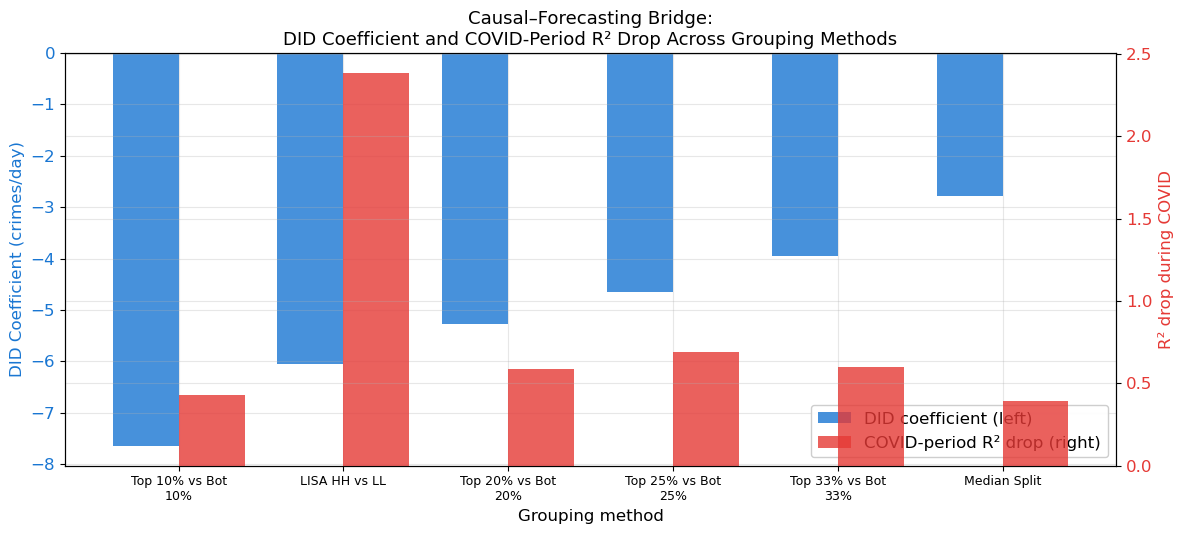

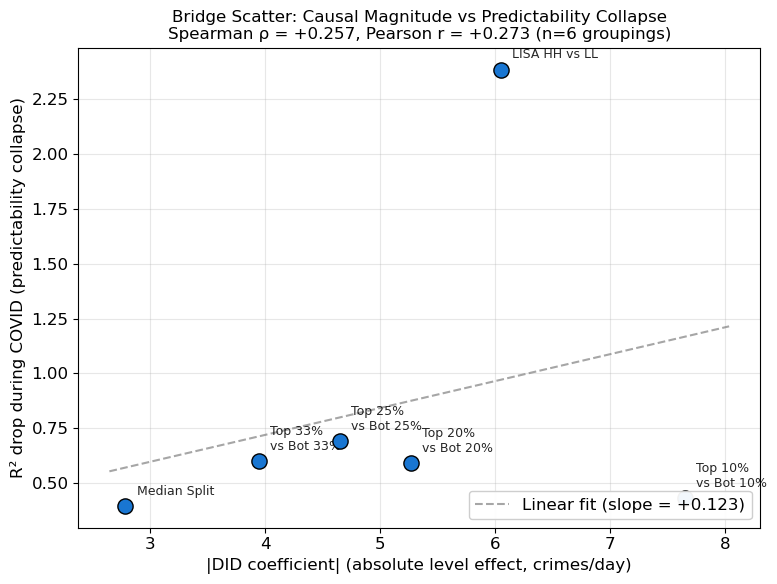

Bridge table saved to: ./figures/nb06b/bridge_table.csv

Final bridge table:
          grouping  did_coef  pre_covid_r2  during_r2  post_covid_r2  r2_drop  n_high  n_windows
     LISA HH vs LL    -6.047      0.816108  -1.569895      -0.584800 2.386003      11         12
Top 10% vs Bot 10%    -7.650      0.646535   0.214171      -0.263302 0.432364       8         12
Top 20% vs Bot 20%    -5.272      0.825721   0.236169       0.068716 0.589552      16         12
Top 25% vs Bot 25%    -4.648      0.877039   0.187169       0.258853 0.689870      20         12
Top 33% vs Bot 33%    -3.949      0.897836   0.297350       0.462766 0.600485      26         12
      Median Split    -2.788      0.936548   0.541677       0.645498 0.394872      38         12


In [1]:
# NB06B: Causal–Forecasting Bridge

# Tests whether DID magnitude and COVID-period R² drop covary across 6 grouping methods. Rolling-window XGBoost on high-crime subgroups,
# 2018–2022, stepped by 3 months. Result: Spearman ρ = +0.257 (n.s.).
# Referenced in §5.5 as preliminary/future work.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import warnings
import os

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.figsize': (14, 6), 'font.size': 12,
                     'axes.grid': True, 'grid.alpha': 0.3})

FIGURE_DIR = './figures/nb06b'
os.makedirs(FIGURE_DIR, exist_ok=True)

panel = pd.read_parquet('./data/panel_ca_daily_v2.parquet')
panel['date'] = pd.to_datetime(panel['date'])
panel['community_area'] = panel['community_area'].astype(str)
print(f"Panel: {panel.shape[0]:,} x {panel.shape[1]}")

# 1. Define the 6 grouping methods
# These exactly match the groupings used in NB07's sensitivity analysis, so the DID coefficients we pair with R² drops are taken from NB07
# (no re-running needed).

# Compute 2019 daily crime mean per community (basis for percentile splits)
ca_crime_2019 = (panel[panel['year'] == 2019]
                 .groupby('community_area')['crime_total']
                 .mean()
                 .sort_values(ascending=False))

n_comm = len(ca_crime_2019)
sorted_ca = ca_crime_2019.index.tolist()

def percentile_split(top_pct, bot_pct):
    n_top = int(np.ceil(n_comm * top_pct))
    n_bot = int(np.ceil(n_comm * bot_pct))
    return set(sorted_ca[:n_top]), set(sorted_ca[-n_bot:])

# LISA grouping (from existing column)
hh_set = set(panel.loc[panel['lisa_cluster'] == 'HH', 'community_area'].unique())
ll_set = set(panel.loc[panel['lisa_cluster'] == 'LL', 'community_area'].unique())

# Build grouping dictionary; we only need the "high" set for forecasting
groupings = {
    'LISA HH vs LL':       (hh_set,                       ll_set),
    'Top 10% vs Bot 10%':  percentile_split(0.10, 0.10),
    'Top 20% vs Bot 20%':  percentile_split(0.20, 0.20),
    'Top 25% vs Bot 25%':  percentile_split(0.25, 0.25),
    'Top 33% vs Bot 33%':  percentile_split(0.33, 0.33),
    'Median Split':        (set(sorted_ca[:n_comm//2]),
                            set(sorted_ca[n_comm//2:])),
}

# DID coefficients from NB07 (already computed there; copy-pasted as the
# anchor for the bridge analysis)
did_coefs = {
    'LISA HH vs LL':      -6.047,
    'Top 10% vs Bot 10%': -7.650,
    'Top 20% vs Bot 20%': -5.272,
    'Top 25% vs Bot 25%': -4.648,
    'Top 33% vs Bot 33%': -3.949,
    'Median Split':       -2.788,
}

print("Grouping setup:")
for label, (high, low) in groupings.items():
    print(f"  {label:<25s} High: {len(high):>3d}  Low: {len(low):>3d}  "
          f"DID = {did_coefs[label]:+.3f}")

# 2. Build monthly panel for forecasting
# Aggregate to community-month, exclude leakage features, define next-month target. Then restrict to 2018–2022 (covering pre-COVID, during, post)
# to keep runtime tractable.

TARGET = 'crime_total'

# Features used for forecasting — match NB06's monthly feature set
monthly_feature_cols = [
    'temp_max', 'temp_min', 'precipitation',
    'poverty_rate', 'unemployment_rate', 'per_capita_income',
    'hardship_index', 'crowded_housing_pct', 'no_highschool_pct',
]

# Aggregate to community-month
panel['ym'] = panel['date'].dt.year * 100 + panel['date'].dt.month
agg_dict = {TARGET: 'mean'}
for c in monthly_feature_cols:
    if c in panel.columns:
        agg_dict[c] = 'mean'

monthly = (panel.groupby(['community_area', 'ym'])
                 .agg(agg_dict)
                 .reset_index())

# Sort and create next-month target
monthly = monthly.sort_values(['community_area', 'ym']).copy()
monthly['target_next_month'] = (
    monthly.groupby('community_area')[TARGET].shift(-1)
)
monthly['date_ym'] = pd.to_datetime(
    monthly['ym'].astype(str), format='%Y%m'
)

# Restrict to 2018–2022 (5 years, sufficient to span pre/during/post-COVID)
monthly = monthly[(monthly['ym'] >= 201801) & (monthly['ym'] <= 202212)].copy()

# Keep features with reasonable coverage
monthly_features = [c for c in monthly_feature_cols
                    if c in monthly.columns and monthly[c].notna().mean() > 0.5]

print(f"\nMonthly rows (2018-2022): {len(monthly):,}")
print(f"Year-months: {monthly['ym'].nunique()}")
print(f"Features used: {monthly_features}")

# 3. Rolling-window forecasting function
# Trains XGBoost on a 24-month window, predicts the next month. Steps the window forward by 3 months (instead of NB06's 1 month) to halve runtime.

def run_rolling_window(df_subset, window_size=24, step=3):
    """
    Run rolling-window XGBoost forecasting on a subset of community-months.
    Returns DataFrame with one row per test month: r2, rmse, n_test.
    """
    all_yms = sorted(df_subset['ym'].unique())
    results = []
    
    for i in range(window_size, len(all_yms) - 1, step):
        train_yms = all_yms[i-window_size:i]
        test_ym = all_yms[i]
        
        train = df_subset[df_subset['ym'].isin(train_yms)].dropna(
            subset=['target_next_month'] + monthly_features
        )
        test = df_subset[df_subset['ym'] == test_ym].dropna(
            subset=['target_next_month'] + monthly_features
        )
        if len(train) < 30 or len(test) < 5:
            continue
        
        X_train = train[monthly_features].fillna(0).values
        y_train = train['target_next_month'].values
        X_test  = test[monthly_features].fillna(0).values
        y_test  = test['target_next_month'].values
        
        model = xgb.XGBRegressor(
            n_estimators=100, max_depth=4, learning_rate=0.1,
            random_state=42, verbosity=0, n_jobs=2,
        )
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2   = r2_score(y_test, y_pred) if len(np.unique(y_test)) > 1 else np.nan
        
        results.append({
            'ym':        test_ym,
            'test_date': pd.to_datetime(str(test_ym), format='%Y%m'),
            'r2':        r2,
            'rmse':      rmse,
            'n_test':    len(test),
        })
    return pd.DataFrame(results)

# 4. Run rolling-window forecasting for each high-crime group
# Expected runtime: ≈30-90 seconds per group × 6 groups = 3-9 minutes total.

covid_start = pd.Timestamp('2020-03-01')
covid_end   = pd.Timestamp('2020-12-31')

bridge_results = []

for label, (high_set, _) in groupings.items():
    print(f"\nRunning rolling-window forecast for high group of: {label}")
    sub = monthly[monthly['community_area'].isin(high_set)].copy()
    print(f"  Communities: {len(high_set)}, monthly rows: {len(sub):,}")
    
    rw = run_rolling_window(sub, window_size=24, step=3)
    
    pre    = rw[rw['test_date'] <  covid_start]['r2'].mean()
    during = rw[(rw['test_date'] >= covid_start) &
                (rw['test_date'] <= covid_end)]['r2'].mean()
    post   = rw[rw['test_date'] >  covid_end]['r2'].mean()
    drop   = pre - during
    
    bridge_results.append({
        'grouping':     label,
        'did_coef':     did_coefs[label],
        'pre_covid_r2': pre,
        'during_r2':    during,
        'post_covid_r2':post,
        'r2_drop':      drop,
        'n_high':       len(high_set),
        'n_windows':    len(rw),
    })
    print(f"  Pre-R²: {pre:.3f}  During-R²: {during:.3f}  Post-R²: {post:.3f}  Drop: {drop:.3f}")

bridge_df = pd.DataFrame(bridge_results)
print("\n" + "="*78)
print("BRIDGE SUMMARY: Causal effect (DID) vs Predictability collapse (R² drop)")
print("="*78)
print(f"\n{'Grouping':<22s} {'DID coef':>10s} {'Pre R²':>8s} {'During':>8s} "
      f"{'R² drop':>9s}")
print("-" * 78)
for _, r in bridge_df.iterrows():
    print(f"{r['grouping']:<22s} {r['did_coef']:>+10.3f} "
          f"{r['pre_covid_r2']:>8.3f} {r['during_r2']:>8.3f} "
          f"{r['r2_drop']:>+9.3f}")

# 5. Compute rank correlation between |DID| and R² drop

from scipy.stats import spearmanr, pearsonr

# We use |DID| because both DID and R²-drop measure "magnitude of disruption"
abs_did = np.abs(bridge_df['did_coef'].values)
r2_drops = bridge_df['r2_drop'].values

rho_spearman, p_spearman = spearmanr(abs_did, r2_drops)
rho_pearson,  p_pearson  = pearsonr(abs_did, r2_drops)

print("\n" + "="*60)
print("CORRELATION ACROSS GROUPINGS")
print("="*60)
print(f"  Spearman ρ (|DID|, R² drop):  {rho_spearman:+.3f}  (p={p_spearman:.4f})")
print(f"  Pearson  r (|DID|, R² drop):  {rho_pearson:+.3f}  (p={p_pearson:.4f})")
print("\nNote: with only 6 groupings, the p-values have very limited power.")
print("The point estimate of the correlation is the more informative figure.")

# 6. Dual-axis plot: DID coefficient and R² drop across groupings

# Sort by |DID| descending (strongest grouping first) for cleaner visual
bridge_sorted = bridge_df.sort_values('did_coef').reset_index(drop=True)

fig, ax1 = plt.subplots(figsize=(12, 5.5))

x_pos = np.arange(len(bridge_sorted))
labels = [g.replace(' vs Bot ', ' vs Bot\n') for g in bridge_sorted['grouping']]

# Left axis: DID coefficient
color1 = '#1976D2'
ax1.bar(x_pos - 0.2, bridge_sorted['did_coef'].values, width=0.4,
        color=color1, alpha=0.8, label='DID coefficient (left)')
ax1.set_xlabel('Grouping method')
ax1.set_ylabel('DID Coefficient (crimes/day)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.axhline(0, color='black', lw=0.6, alpha=0.5)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(labels, fontsize=9)

# Right axis: R² drop
ax2 = ax1.twinx()
color2 = '#E53935'
ax2.bar(x_pos + 0.2, bridge_sorted['r2_drop'].values, width=0.4,
        color=color2, alpha=0.8, label='COVID-period R² drop (right)')
ax2.set_ylabel('R² drop during COVID', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right',
           framealpha=0.95)

plt.title('Causal–Forecasting Bridge:\n'
          'DID Coefficient and COVID-Period R² Drop Across Grouping Methods',
          fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '01_dual_axis_bridge.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# 7. Scatter plot: |DID| vs R² drop with regression line

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(abs_did, r2_drops, s=120, c='#1976D2',
           edgecolor='black', zorder=5)

# Annotate each point with its grouping name
for _, r in bridge_df.iterrows():
    ax.annotate(r['grouping'].replace(' vs Bot', '\nvs Bot'),
                (abs(r['did_coef']), r['r2_drop']),
                xytext=(8, 8), textcoords='offset points',
                fontsize=9, alpha=0.85)

# Fit and plot regression line
if len(abs_did) >= 2:
    coef = np.polyfit(abs_did, r2_drops, 1)
    xx = np.linspace(abs_did.min()*0.95, abs_did.max()*1.05, 50)
    yy = coef[0] * xx + coef[1]
    ax.plot(xx, yy, color='gray', ls='--', alpha=0.7,
            label=f'Linear fit (slope = {coef[0]:+.3f})')

ax.set_xlabel('|DID coefficient| (absolute level effect, crimes/day)')
ax.set_ylabel('R² drop during COVID (predictability collapse)')
ax.set_title(f'Bridge Scatter: Causal Magnitude vs Predictability Collapse\n'
             f'Spearman ρ = {rho_spearman:+.3f}, '
             f'Pearson r = {rho_pearson:+.3f} (n=6 groupings)',
             fontsize=12)
ax.legend(loc='lower right', framealpha=0.95)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '02_bridge_scatter.png'),
            dpi=150, bbox_inches='tight')
plt.show()


# 8. Save bridge table for reference / inclusion in report

bridge_df.to_csv(os.path.join(FIGURE_DIR, 'bridge_table.csv'), index=False)
print(f"Bridge table saved to: {FIGURE_DIR}/bridge_table.csv")
print("\nFinal bridge table:")
print(bridge_df.to_string(index=False))